
Options:
1. Add expense
2. Remove expense by row number
3. Edit expense by row number
4. Quit


Select option (1/2/3/4):  1
Enter expense (e.g. 'spent 20 at starbucks'):  spent 30 in gym



Current Expense Table:
+----+----------+------------+---------------+-----------------+
|    |   Amount | Date       | Category      | Description     |
+====+==========+============+===============+=================+
|  0 |       60 | 2025-09-18 | Health        | gym             |
+----+----------+------------+---------------+-----------------+
|  1 |       70 | 2025-09-18 | Food          | starbucks       |
+----+----------+------------+---------------+-----------------+
|  2 |       60 | 2025-09-18 | Entertainment | movie           |
+----+----------+------------+---------------+-----------------+
|  3 |       70 | 2025-09-18 | Entertainment | movie           |
+----+----------+------------+---------------+-----------------+
|  4 |      250 | 2025-09-18 | Groceries     | grocery         |
+----+----------+------------+---------------+-----------------+
|  5 |       60 | 2025-09-18 | Groceries     | grocery         |
+----+----------+------------+---------------+-----------------+
|

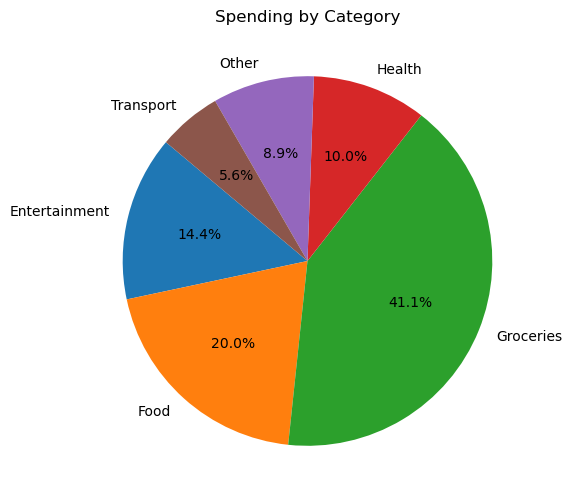


Options:
1. Add expense
2. Remove expense by row number
3. Edit expense by row number
4. Quit


Select option (1/2/3/4):  2



Current Expense Table:
+----+----------+------------+---------------+-----------------+
|    |   Amount | Date       | Category      | Description     |
+====+==========+============+===============+=================+
|  0 |       60 | 2025-09-18 | Health        | gym             |
+----+----------+------------+---------------+-----------------+
|  1 |       70 | 2025-09-18 | Food          | starbucks       |
+----+----------+------------+---------------+-----------------+
|  2 |       60 | 2025-09-18 | Entertainment | movie           |
+----+----------+------------+---------------+-----------------+
|  3 |       70 | 2025-09-18 | Entertainment | movie           |
+----+----------+------------+---------------+-----------------+
|  4 |      250 | 2025-09-18 | Groceries     | grocery         |
+----+----------+------------+---------------+-----------------+
|  5 |       60 | 2025-09-18 | Groceries     | grocery         |
+----+----------+------------+---------------+-----------------+
|

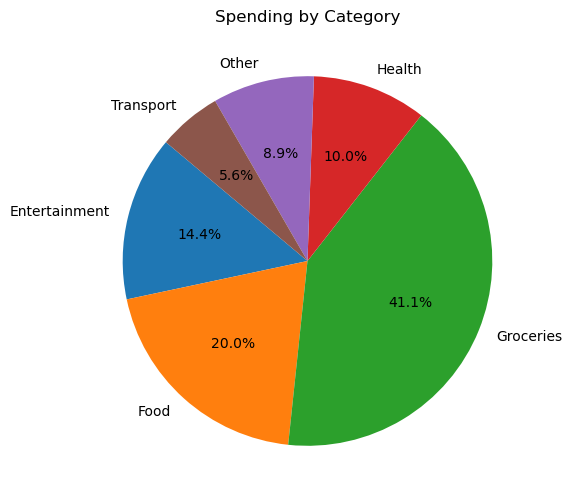

Enter the row number to remove:  11


✅ Removed entry: {'Amount': 30.0, 'Date': '2025-09-25', 'Category': 'Health', 'Description': 'spent 30 in gym'}

Current Expense Table:
+----+----------+------------+---------------+---------------+
|    |   Amount | Date       | Category      | Description   |
+====+==========+============+===============+===============+
|  0 |       60 | 2025-09-18 | Health        | gym           |
+----+----------+------------+---------------+---------------+
|  1 |       70 | 2025-09-18 | Food          | starbucks     |
+----+----------+------------+---------------+---------------+
|  2 |       60 | 2025-09-18 | Entertainment | movie         |
+----+----------+------------+---------------+---------------+
|  3 |       70 | 2025-09-18 | Entertainment | movie         |
+----+----------+------------+---------------+---------------+
|  4 |      250 | 2025-09-18 | Groceries     | grocery       |
+----+----------+------------+---------------+---------------+
|  5 |       60 | 2025-09-18 | Groceries     

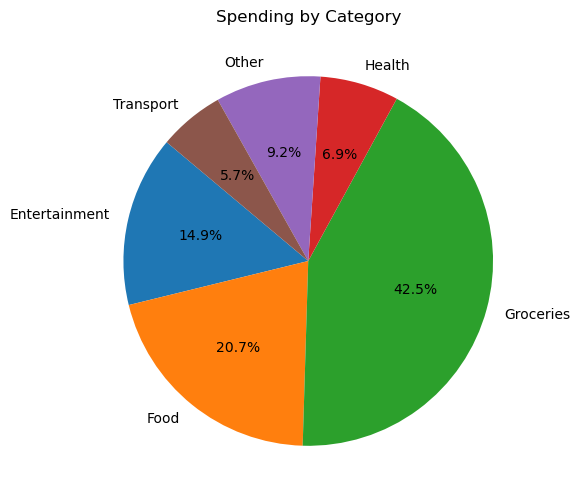


Options:
1. Add expense
2. Remove expense by row number
3. Edit expense by row number
4. Quit


In [ ]:
import pandas as pd
import re
from datetime import datetime
from tabulate import tabulate
import os
import matplotlib.pyplot as plt

# Initialize an empty DataFrame to store entriesq

DATA_FILE = "expenses.csv"
if os.path.exists(DATA_FILE):
    data = pd.read_csv(DATA_FILE)
else:
    data = pd.DataFrame(columns=["Amount", "Date", "Category", "Description"])

# Simple keyword-based category mapping
CATEGORY_MAP = {
    "Food": ["starbucks", "mcdonalds", "restaurant", "coffee", "burgerking"],
    "Groceries": ["grocery", "supermarket", "walmart"],
    "Transport": ["uber", "taxi", "bus"],
    "Entertainment": ["movie", "cinema", "netflix"],
    "Health": ["gym", "doctor", "medicine"]
}
def extract_date(line):
    """Detect date in various formats and normalize to YYYY-MM-DD"""
    patterns = [
        r"\b(\d{4})-(\d{2})-(\d{2})\b",      # 2025-03-25
        r"\b(\d{2})/(\d{2})/(\d{2,4})\b",    # 25/03/25 or 25/03/2025
        r"\b(\d{2})-(\d{2})-(\d{2,4})\b"     # 25-03-25 or 25-03-2025
    ]

    for pat in patterns:
        match = re.search(pat, line)
        if match:
            groups = match.groups()
            # YYYY-MM-DD
            if len(groups[0]) == 4:
                return f"{groups[0]}-{groups[1]}-{groups[2]}"
            else:  # DD/MM/YY or DD-MM-YY
                day = groups[0]
                month = groups[1]
                year = groups[2]
                if len(year) == 2:
                    year = "20" + year
                return f"{year}-{month}-{day}"
    # Default to today's date
    return datetime.today().strftime("%Y-%m-%d")
    
def remove_dates(text):
    """Remove dates in multiple formats from text"""
    date_patterns = [
        r"\b\d{4}-\d{2}-\d{2}\b",   # 2025-03-25
        r"\b\d{2}/\d{2}/\d{2,4}\b", # 25/03/25 or 25/03/2025
        r"\b\d{2}-\d{2}-\d{2,4}\b"  # 25-03-25 or 25-03-2025
    ]
    for pat in date_patterns:
        text = re.sub(pat, "", text)
    return text.strip()


def parse_line(line):
    # Extract amount
    amount_match = re.search(r"\d+(\.\d+)?", line)
    amount = float(amount_match.group()) if amount_match else 0.0

    # Extract date if mentioned, else today's date
    date = extract_date(line)


    # Lowercase text for matching
    text = line.lower()

    # Find category based on keywords
    category = "Other"
    for cat, keywords in CATEGORY_MAP.items():
        for keyword in keywords:
            if keyword in text:
                category = cat
                break
        if category != "Other":
            break

    # Description = words after 'at' or 'on', else just the line
    desc_match = re.search(r"(?:at|on|for|to|in)\s+(.+)", text)
    description = desc_match.group(1) if desc_match else text

    # Remove any dates from description
    description = remove_dates(description)
    

    return amount, date, category, description

def print_table_and_summary():
    print("\nCurrent Expense Table:")
    print(tabulate(data, headers="keys", tablefmt="grid", showindex=True))
    print(f"\nTotal Amount: {data['Amount'].sum():.2f}\n")

    # Category-wise summary
    cat_summary = data.groupby("Category")["Amount"].sum().reset_index()
    print("Category-wise Summary:")
    print(tabulate(cat_summary, headers="keys", tablefmt="grid", showindex=False))

    # Plot pie chart
    plt.figure(figsize=(6,6))
    plt.pie(cat_summary["Amount"], labels=cat_summary["Category"], autopct="%1.1f%%", startangle=140)
    plt.title("Spending by Category")
    plt.show()
    
  

while True:
    print("\nOptions:")
    print("1. Add expense")
    print("2. Remove expense by row number")
    print("3. Edit expense by row number")
    print("4. Quit")
    choice = input("Select option (1/2/3/4): ")

    if choice == "1":
        line = input("Enter expense (e.g. 'spent 20 at starbucks'): ")
        try:
            amount, date, category, description = parse_line(line)
            data.loc[len(data)] = [amount, date, category, description]
            print_table_and_summary()
        except Exception:
            print("⚠️ Could not parse line. Try again.")

    elif choice == "2":
        if data.empty:
            print("No entries to remove.")
            continue
        print_table_and_summary()
        try:
            row = int(input("Enter the row number to remove: "))
            if 0 <= row < len(data):
                removed = data.loc[row]
                data = data.drop(row).reset_index(drop=True)
                print(f"✅ Removed entry: {removed.to_dict()}")
                print_table_and_summary()
            else:
                print("⚠️ Invalid row number.")
        except ValueError:
            print("⚠️ Please enter a valid integer row number.")

    elif choice == "3":
        if data.empty:
            print("No entries to edit.")
            continue
        print_table_and_summary()
        try:
            row = int(input("Enter the row number to edit: "))
            if 0 <= row < len(data):
                print("Enter new expense details in natural language (e.g. 'spent 30 at McDonalds on 25/09/25').")
                print("Leave blank to keep current entry.")
                current = data.loc[row]
                line = input(f"Current entry: Amount={current['Amount']}, Date={current['Date']}, Category={current['Category']}, Description={current['Description']}\nNew entry: ")

                if line.strip():
                    amount, date, category, description = parse_line(line)
                    data.loc[row] = [amount, date, category, description]
                    print("✅ Entry updated.")
                else:
                    print("⚠️ No changes made.")

                print_table_and_summary()
            else:
                print("⚠️ Invalid row number.")
        except ValueError:
            print("⚠️ Please enter a valid integer row number.")
            
    elif choice == "4":
        data.to_csv(DATA_FILE, index=False)
        print("✅ Data saved. Goodbye!")
        break

    else:
        print("⚠️ Invalid option. Choose 1, 2, 3, or 4.")